# Cart-pole: stabilizing an unstable equilibrium

The model is the declared cart-pole from [`models/cart_pole.py`](models/cart_pole.py):
an inverted pendulum on a cart, four states, one force input, starting from a
40-degree tilt. The upright target is an unstable equilibrium, the regime
where short-horizon NMPC visibly fails and terminal machinery earns its keep.
Two cases of the same model. Case 1 runs five sampling steps with the
infinite-horizon terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live. The pole is fast relative to the one-second sampling, so
both cases discretize with five collocation points per element.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.cart_pole import cart_pole
from drto import plot_states, plot_controls, plot_stage_cost

m1 = cart_pole(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=5, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmps5ao9phd.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmps5ao9phd.pyomo.nl...
Parsed 377 vars, 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 357, 'Number of variables': 377, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.9.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.8375296592712402}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

<drto registry>
states: 4, controls: 1
declarations:
  horizon: t (ContinuousSet, 26 points)
  states: x (free), x_dot (free), theta (free), theta_dot (free)
  dynamics: dx[t]  ==  x_dot[t]  for t in t
  dynamics: dx_dot[t]  ==  (m_p*g*sin(theta[t])*cos(theta[t]) - (1 + kJ)*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t]) - b*x_dot[t]))/(m_p*cos(theta[t])**2 - (1 + kJ)*m_c)  for t in t
  dynamics: dtheta[t]  ==  theta_dot[t]  for t in t
  dynamics: dtheta_dot[t]  ==  (m_c*g*sin(theta[t]) - cos(theta[t])*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t])))/((1 + kJ)*m_c*l - m_p*l*cos(theta[t])**2)  for t in t
  controls: F (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (theta[t] - theta_ss)**2/theta_scale**2 + 0.01*(x[t] - x_ss)**2 + 0.01*(x_dot[t] - x_dot_ss)**2 + 0.01*(theta_dot[t] - theta_dot_ss)**2/theta_scale**2 + 0.1*(F[t] - F_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  (theta[5] - theta_ss)**2/theta_scale**2 + 0.01*(x[5] - x_ss)**2 + 0.01*(x_dot[5] - x_dot_ss)**2 + 0.01*(theta_dot[5] - theta_dot_ss)**2/theta_scale**2
  initial conditions: x[0]  ==  x_hat
  initial conditions: x_dot[0]  ==  x_dot_hat
  initial conditions: theta[0]  ==  theta_hat
  initial conditions: theta_dot[0]  ==  theta_dot_hat
  steady-state targets: x_ss (of x), x_dot_ss (of x_dot), theta_ss (of theta), theta_dot_ss (of theta_dot)
  steady-state control targets: F_ss (of F)
  cost_group: drto_ih, drto_ih
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.01563827, profile=collocation, horizon=kept, infinite tail appended, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 4 states, mu=1000.0
  drto.parameterize: profiles=F (piecewise_constant)
  drto.build_objective: objective=sum of 36 weighted cost terms

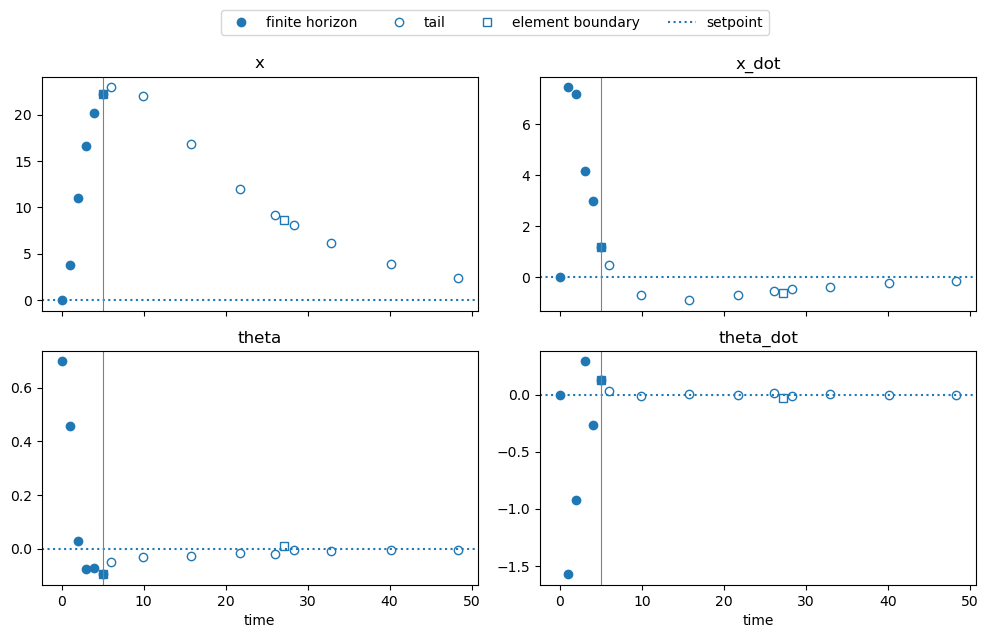

In [3]:
plot_states(m1);

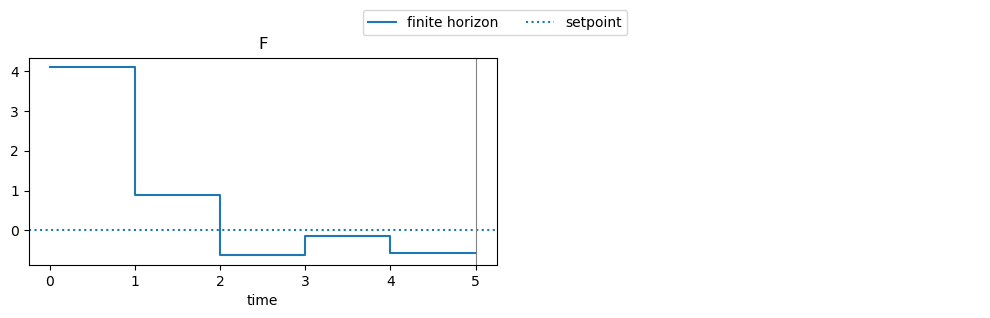

In [4]:
plot_controls(m1);

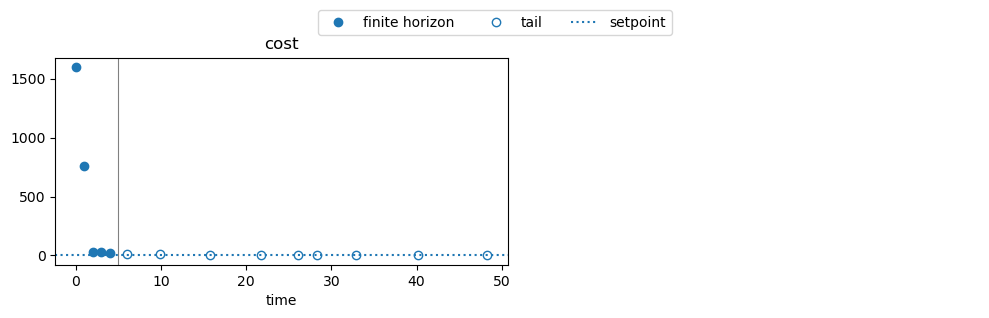

In [5]:
plot_stage_cost(m1);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = cart_pole(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=5, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpq_c6w5jc.pyomo.nl...
Parsed 2109 vars,

   4 -4.6770252e+04 7.64e+01 1.15e+02   -1.0 6.33e+03      - 3.18e-01 7.55e-02f  1
   5 -5.0413828e+04 4.72e+01 7.73e+02   -1.0 2.54e+03      - 2.74e-01 4.02e-01f  1
   6 -4.1930022e+04 3.82e+01 6.46e+02   -1.0 1.58e+03      - 5.82e-02 1.97e-01h  1
   7 -4.1629198e+04 3.79e+01 6.41e+02   -1.0 1.34e+03      - 1.72e-01 7.67e-03h  1
   8 -2.9039559e+03 1.10e+01 1.03e+03   -1.0 1.28e+03      - 2.92e-02 1.00e+00h  1
   9 -2.2650663e+03 9.90e+00 9.32e+02   -1.0 5.30e+02      - 6.09e-02 9.73e-02h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10 -1.2929261e+03 8.07e+00 7.59e+02   -1.0 4.06e+02      - 1.13e-02 1.85e-01h  1
  11  1.9969655e+02 7.81e+00 4.39e+02   -1.0 5.71e+02      - 3.07e-03 7.22e-01h  1
  12  2.4535278e+03 5.30e-01 9.94e+01   -1.0 3.33e+02      - 7.94e-01 1.00e+00h  1
  13  2.5850139e+03 1.59e-02 6.73e-02   -1.0 2.43e+01      - 1.00e+00 9.71e-01h  1
  14  2.5893872e+03 1.47e-06 1.24e-06   -2.5 7.28e-01      - 1.00e+00 1.00e+00h  1
  15

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 2059, 'Number of variables': 2109, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.9.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.9364895820617676}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [7]:
drto.info(m2)

<drto registry>
states: 4, controls: 1
declarations:
  horizon: t (ContinuousSet, 251 points)
  states: x (free), x_dot (free), theta (free), theta_dot (free)
  dynamics: dx[t]  ==  x_dot[t]  for t in t
  dynamics: dx_dot[t]  ==  (m_p*g*sin(theta[t])*cos(theta[t]) - (1 + kJ)*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t]) - b*x_dot[t]))/(m_p*cos(theta[t])**2 - (1 + kJ)*m_c)  for t in t
  dynamics: dtheta[t]  ==  theta_dot[t]  for t in t
  dynamics: dtheta_dot[t]  ==  (m_c*g*sin(theta[t]) - cos(theta[t])*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t])))/((1 + kJ)*m_c*l - m_p*l*cos(theta[t])**2)  for t in t
  controls: F (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (theta[t] - theta_ss)**2/theta_scale**2 + 0.01*(x[t] - x_ss)**2 + 0.01*(x_dot[t] - x_dot_ss)**2 + 0.01*(theta_dot[t] - theta_dot_ss)**2/theta_scale**2 + 0.1*(F[t] - F_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  (theta[50] - theta_ss)**2/theta_scale**2 + 0.01*(x[50] - x_ss)**2 + 0.01*(x_dot[50] - x_dot_ss)**2 + 0.01*(theta_dot[50] - theta_dot_ss)**2/theta_scale**2
  initial conditions: x[0]  ==  x_hat
  initial conditions: x_dot[0]  ==  x_dot_hat
  initial conditions: theta[0]  ==  theta_hat
  initial conditions: theta_dot[0]  ==  theta_dot_hat
  steady-state targets: x_ss (of x), x_dot_ss (of x_dot), theta_ss (of theta), theta_dot_ss (of theta_dot)
  steady-state control targets: F_ss (of F)
transformations:
  drto.parameterize: profiles=F (piecewise_constant)
  drto.build_objective: objective=sum of 51 weighted cost terms

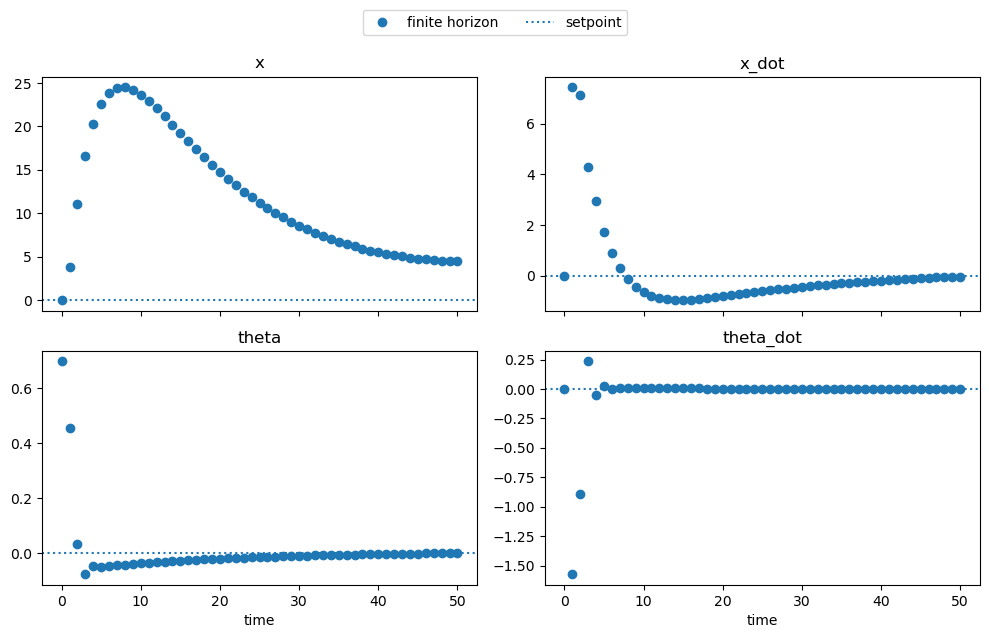

In [8]:
plot_states(m2);

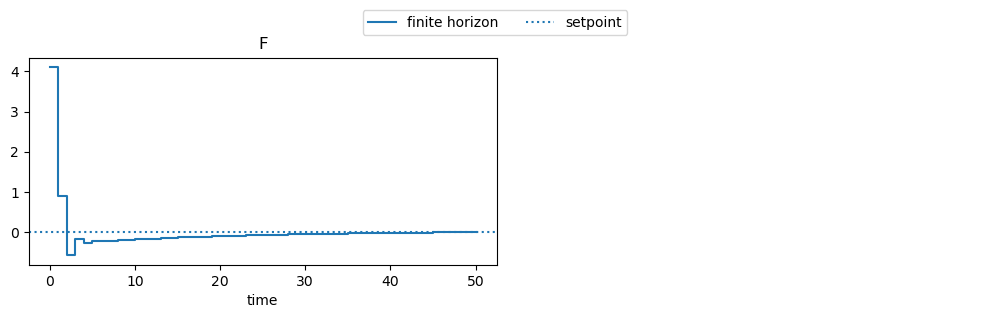

In [9]:
plot_controls(m2);

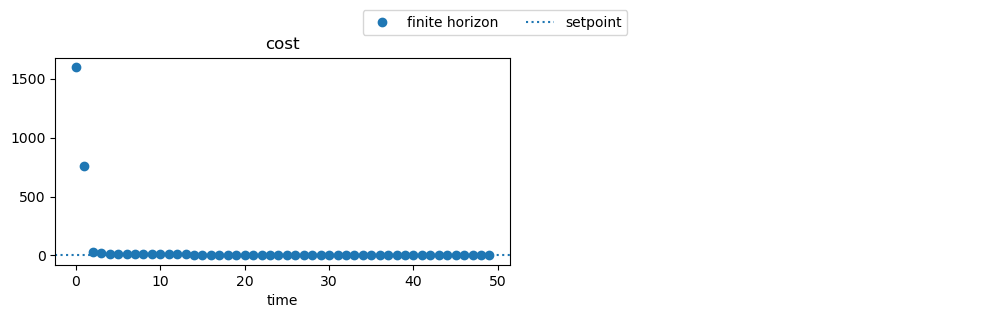

In [10]:
plot_stage_cost(m2);